# 🧠 03 - Model Training & Comparison
## AMEEMAW: AI Mamma-Echography Educator & Empathetic Mentor for Awareness & Wellness

**Author:** Shira Amina Ortiz Olivares  
**Date:** December 2025  
**Dataset:** Breast Ultrasound Images (BUSI)

---

### 🐧 Welcome to the main event — Model Training!

This is where the magic happens. We're going to train **10 different models** and compare them head-to-head. 🏆

**What we're training:**

| CNN Models (on images) | Tabular Models (on radiomics) |
|------------------------|-------------------------------|
| EfficientNet-B0 | Logistic Regression |
| ResNet-50 | Random Forest |
| VGG-16 | XGBoost |
| MobileNetV2 | SVM (RBF kernel) |
| Custom CNN | MLP (Neural Network) |

💡 **Why both?** CNNs learn directly from pixels — they figure out their own features. Tabular models use handcrafted radiomics features — interpretable and clinically meaningful.

---

## 1. 🛠️ Colab Setup

In [ ]:
# ============================================
# COLAB SETUP
# Install required packages + check GPU
# ============================================

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🐧 Running in Google Colab!")
    !pip install -q xgboost

    import torch
    if torch.cuda.is_available():
        print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
        print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        print("⚠️ No GPU! Go to Runtime → Change runtime type → GPU")
else:
    print("💻 Running locally")

🐧 Running in Google Colab!
✅ GPU detected: Tesla T4
   Memory: 15.8 GB


## 2. 📦 Imports

In [ ]:
# ============================================
# IMPORTS
# ============================================

import os
import json
import time
import pickle
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50, ResNet50_Weights,
    vgg16, VGG16_Weights,
    mobilenet_v2, MobileNet_V2_Weights
)

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

# XGBoost
import xgboost as xgb

from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("✅ All imports successful!")
print(f"   PyTorch: {torch.__version__}")
print(f"   Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

✅ All imports successful!
   PyTorch: 2.9.0+cu126
   Device: CUDA


## 3. 📂 Path Configuration & Data Loading

🐧 Let's load everything we prepared in notebooks 01 and 02!

In [ ]:
# ============================================
# PATH CONFIGURATION
# ============================================

if IN_COLAB:
    #!unzip -q /content/Dataset_BUSI_with_GT.zip -d /content/                        # uncomment this is you uploaded a ZIP version
    BASE_DIR = Path('/content')
    DATA_DIR = BASE_DIR / 'Dataset_BUSI_with_GT'
else:
    BASE_DIR = Path('.').resolve().parent
    DATA_DIR = BASE_DIR / 'data' / 'raw' / 'Dataset_BUSI_with_GT'

PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
MODELS_DIR = BASE_DIR / 'models'
FIGURES_DIR = BASE_DIR / 'reports' / 'figures'

for dir_path in [PROCESSED_DIR, MODELS_DIR, FIGURES_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print("📂 Directory Structure:")
print(f"   Base: {BASE_DIR}")
print(f"   Data: {DATA_DIR}")
print(f"   Models: {MODELS_DIR}")

📂 Directory Structure:
   Base: /content
   Data: /content/Dataset_BUSI_with_GT
   Models: /content/models


In [ ]:
# ============================================
# LOAD SPLIT DATA FROM FEATURE ENGINEERING
# ============================================

train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'val.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test.csv')

print("🐧 Data splits loaded!")
print(f"   Train: {len(train_df)} samples")
print(f"   Val:   {len(val_df)} samples")
print(f"   Test:  {len(test_df)} samples")

# Load class weights
class_weights = torch.load(MODELS_DIR / 'class_weights.pt')
print(f"\n⚖️ Class weights: {class_weights}")

🐧 Data splits loaded!
   Train: 546 samples
   Val:   117 samples
   Test:  117 samples

⚖️ Class weights: tensor([1.9570, 0.5948, 1.2381])


In [ ]:
# ============================================
# LOAD RADIOMICS FOR TABULAR MODELS
# ============================================

radiomics_df = pd.read_csv(PROCESSED_DIR / 'radiomics_features.csv')

# Extract feature names directly from CSV (skip corrupted pkl files - my ipynb 02 outputs got corrupted and I do not want to rerun!!!)
metadata_cols = ['filename', 'class_name', 'class_encoded', 'split']
feature_names = [c for c in radiomics_df.columns if c not in metadata_cols]

print(f"🐧 Radiomics loaded!")
print(f"   Samples: {len(radiomics_df)}")
print(f"   Features: {len(feature_names)}")

🐧 Radiomics loaded!
   Samples: 645
   Features: 104


---

## 4. 🖼️ CNN Data Pipeline

🐧 Time to build the image data pipeline!

### 🐧💡 Why These Specific Settings:

**Image Size (224x224):** Standard input size for ImageNet-pretrained models. The pretrained weights expect this!

**ImageNet Normalization:** The pretrained models were trained on ImageNet with mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225]. Using the same stats ensures the model "speaks the same language" — pixels are scaled exactly how it learned to interpret them.

**Rotation ±15°:** Why not 30° or 45°? As explained in the previous .ipynb, medical images have anatomical orientation that matters. Too much rotation could flip the meaning (left vs right). 15° is enough variety without confusing anatomy.

In [ ]:
# ============================================
# CONFIGURATION
# ============================================

IMG_SIZE = 224
NUM_CLASSES = 3
BATCH_SIZE = 32
NUM_EPOCHS = 30              # initially at 20 but not-so-good results
LEARNING_RATE = 5e-5         # was 1e-4 (half the speed, more precise updates)
PATIENCE = 7                 # was 5. hopefully lucky 7!

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("⚙️ CNN Training Configuration")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: {NUM_EPOCHS} (with early stopping)")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Device: {DEVICE}")

⚙️ CNN Training Configuration
   Image size: 224x224
   Batch size: 32
   Epochs: 30 (with early stopping)
   Learning rate: 5e-05
   Device: cuda


In [ ]:
# ============================================
# DATA TRANSFORMS
# ============================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training: with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),  # ±15° — mild rotation for medical images
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # was 0.1 — more lighting variation [I changed it in hopes that perf will be better][update: it got worse lol. turning back to 0.1]
    #transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # NEW: shift image up to 10% — simulates lesion in different positions [added to see if perf will be better][got worse. will remove]
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Val/Test: no augmentation
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("✅ Transforms defined!")

✅ Transforms defined!


In [ ]:
# ============================================
# CUSTOM DATASET CLASS
# ============================================

class BUSIDataset(Dataset):
    """Custom PyTorch Dataset for BUSI images."""

    def __init__(self, dataframe, data_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.data_dir / row['image_path']
        label = row['class_encoded']

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, label

# Create datasets
train_dataset = BUSIDataset(train_df, DATA_DIR, transform=train_transforms)
val_dataset = BUSIDataset(val_df, DATA_DIR, transform=eval_transforms)
test_dataset = BUSIDataset(test_df, DATA_DIR, transform=eval_transforms)

print(f"🐧 Datasets created!")
print(f"   Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

🐧 Datasets created!
   Train: 546, Val: 117, Test: 117


### 🐧💡 WeightedRandomSampler — Our Secret Weapon!

Remember our class imbalance? (Benign: 437, Malignant: 210, Normal: 133)

| Method | How It Works | Why We Didn't Choose It |
|--------|--------------|-------------------------|
| **Oversampling** | Duplicate minority samples | Risk of overfitting to duplicates |
| **Undersampling** | Remove majority samples | We lose valuable data! |
| **SMOTE** | Generate synthetic samples | Doesn't work well for images |
| **Class Weights** ✅ | Penalize majority mistakes less | Good, but batches still imbalanced |
| **WeightedRandomSampler** ✅ | Sample minority more often | Balanced batches every epoch! |

💡 **We use BOTH class weights AND weighted sampling** — belt AND suspenders! The sampler ensures each batch is balanced, while class weights fine-tune the loss function.

In [ ]:
# ============================================
# WEIGHTED RANDOM SAMPLER
# ============================================

sample_weights = torch.load(MODELS_DIR / 'sample_weights.pt')

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # Same image can appear multiple times per epoch
)

print("⚖️ WeightedRandomSampler created!")
print(f"   Samples: {len(sample_weights)}")

⚖️ WeightedRandomSampler created!
   Samples: 546


In [ ]:
# ============================================
# DATALOADERS
# ============================================

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=train_sampler, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"✅ DataLoaders ready!")
print(f"   Train batches: {len(train_loader)}")

✅ DataLoaders ready!
   Train batches: 18


---

## 5. 🏗️ CNN Model Architectures

🐧 Let's define our 5 CNN architectures!

### 💡 Transfer Learning Strategy
1. Load pretrained weights (trained on 14M ImageNet images)
2. Replace final layer for our 3 classes
3. Fine-tune on our data

Why this works: Early layers learn universal features (edges, textures) that transfer across domains!

In [ ]:
# ============================================
# MODEL FACTORY FUNCTIONS
# ============================================

def get_efficientnet_b0(num_classes=3):
    """EfficientNet-B0: Best accuracy/efficiency trade-off!"""
    # Load model pretrained on ImageNet (14M images, 1000 classes)
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    # Get the size of features going into the final layer
    in_features = model.classifier[1].in_features
    # Replace the 1000-class head with our 3-class head
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),  # Randomly zero 30% of neurons to prevent overfitting
        nn.Linear(in_features, num_classes)  # Final layer: features → 3 classes
    )
    return model

def get_resnet50(num_classes=3):
    """ResNet-50: The workhorse of medical imaging!"""
    # V2 weights = better preprocessing, slightly improved accuracy
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    in_features = model.fc.in_features  # fc = "fully connected" (final layer)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

def get_vgg16(num_classes=3):
    """VGG-16: Simple architecture, great for Grad-CAM!"""
    model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
    in_features = model.classifier[6].in_features  # VGG has 7 classifier layers, we replace #6
    # No dropout here — VGG already has dropout built into its classifier
    model.classifier[6] = nn.Linear(in_features, num_classes)
    return model

def get_mobilenet_v2(num_classes=3):
    """MobileNetV2: Lightweight, perfect for deployment!"""
    # Only ~3.4M params vs VGG's 138M — runs fast on phones!
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V2)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

class CustomCNN(nn.Module):
    """Custom CNN: Our own design, trained from scratch!"""

    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 224 -> 112 (halved by MaxPool)
            nn.Conv2d(3, 32, 3, padding=1),  # 3 input channels (RGB), 32 output filters
            nn.BatchNorm2d(32),  # Normalize outputs — helps training stability
            nn.ReLU(),  # Activation: if negative → 0, else keep value
            nn.MaxPool2d(2),  # Take max of each 2x2 region → shrinks image by half

            # Block 2-5: Same pattern, doubling filters each time (32→64→128→256→512)
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Squeeze 7x7 → 1x1 (global average)
            nn.Flatten(),  # 512x1x1 → 512 (flatten for linear layer)
            nn.Dropout(0.5),  # 50% dropout — aggressive because training from scratch
            nn.Linear(512, 256),  # Reduce dimensions
            nn.ReLU(),
            nn.Dropout(0.3),  # Lighter dropout before final layer
            nn.Linear(256, num_classes)  # Final prediction
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def get_custom_cnn(num_classes=3):
    return CustomCNN(num_classes)

# Model registry — lets us loop through all models easily
CNN_MODELS = {
    'EfficientNet-B0': get_efficientnet_b0,
    'ResNet-50': get_resnet50,
    'VGG-16': get_vgg16,
    'MobileNetV2': get_mobilenet_v2,
    'Custom-CNN': get_custom_cnn
}

print("✅ CNN architectures defined!")
print(f"   Models: {list(CNN_MODELS.keys())}")

✅ CNN architectures defined!
   Models: ['EfficientNet-B0', 'ResNet-50', 'VGG-16', 'MobileNetV2', 'Custom-CNN']


In [ ]:
# ============================================
# MODEL SIZE COMPARISON
# ============================================

print("📊 Model Size Comparison")
print("=" * 50)
print(f"{'Model':<18} {'Parameters':>12} {'Size (MB)':>10}")
print("-" * 50)

for name, factory in CNN_MODELS.items():
    model = factory(NUM_CLASSES)
    params = sum(p.numel() for p in model.parameters())
    size_mb = params * 4 / (1024 ** 2)
    print(f"{name:<18} {params:>12,} {size_mb:>8.1f} MB")
    del model

print("\n💡 MobileNetV2 is ~60x smaller than VGG-16 — great for deployment!")

📊 Model Size Comparison
Model                Parameters  Size (MB)
--------------------------------------------------
EfficientNet-B0       4,011,391     15.3 MB
ResNet-50            23,514,179     89.7 MB
VGG-16              134,272,835    512.2 MB
MobileNetV2           2,227,715      8.5 MB
Custom-CNN            1,702,659      6.5 MB

💡 MobileNetV2 is ~60x smaller than VGG-16 — great for deployment!


---

## 6. 🎯 Training Infrastructure

In [ ]:
# ============================================
# EARLY STOPPING
# Prevents overfitting by stopping when model stops improving
# ============================================

class EarlyStopping:
    """Stop training when val loss stops improving."""

    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience      # How many epochs to wait before giving up
        self.min_delta = min_delta    # Minimum improvement to count as "better" (ignores tiny fluctuations)
        self.best_loss = float('inf') # Start with infinity so any loss is better
        self.counter = 0              # Counts epochs without improvement
        self.best_weights = None      # Stores the best model weights we've seen
        self.early_stop = False       # Flag to signal "stop training!"

    def __call__(self, val_loss, model):
        # Did we improve by at least min_delta?
        if val_loss < self.best_loss - self.min_delta:
            # Yes! Save this as our new best
            self.best_loss = val_loss
            self.counter = 0  # Reset patience counter
            # Save a copy of model weights (move to CPU to save GPU memory)
            self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            # No improvement — tick the patience counter
            self.counter += 1
            if self.counter >= self.patience:
                # Out of patience! Stop training
                self.early_stop = True
                # Restore the best weights we saved (not the current overfit ones)
                if self.best_weights:
                    model.load_state_dict(self.best_weights)
        return self.early_stop

print("✅ EarlyStopping defined!")

✅ EarlyStopping defined!


In [ ]:
# ============================================
# TRAINING FUNCTIONS
# ============================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # Enable training mode (dropout active, batchnorm updates)
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # Clear old gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backprop: compute gradients
        optimizer.step()  # Update weights

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)  # Get class with highest score
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()  # Disable dropout, freeze batchnorm
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():  # No gradients needed — saves memory & speeds up
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            probs = torch.softmax(outputs, dim=1)  # Convert logits → probabilities
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())  # Keep probs for AUC-ROC later

    return (running_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

print("✅ Training functions defined!")

✅ Training functions defined!


In [ ]:
# ============================================
# FULL TRAINING PIPELINE
# ============================================

def train_cnn_model(model_name, model, train_loader, val_loader,
                    num_epochs, lr, class_weights, device, patience=5, save_dir=None):
    print(f"\n{'='*60}")
    print(f"🚀 Training {model_name}")
    print(f"{'='*60}")

    model = model.to(device)
    # CrossEntropyLoss with weights — penalizes minority class mistakes more
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    # AdamW = Adam + weight decay (L2 regularization baked in properly)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # If val_loss plateaus for 2 epochs, cut learning rate in half
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    early_stopping = EarlyStopping(patience=patience)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    start_time = time.time()
    best_val_acc = 0

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)  # Check if we should reduce LR

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        print(f"Epoch {epoch+1:02d}/{num_epochs} | "
              f"Train: {train_loss:.4f}/{train_acc:.4f} | "
              f"Val: {val_loss:.4f}/{val_acc:.4f}")

        if early_stopping(val_loss, model):
            print(f"⏹️ Early stopping at epoch {epoch+1}")
            break

    training_time = time.time() - start_time

    # Save model weights + training history for later analysis
    if save_dir:
        save_path = Path(save_dir) / f"{model_name.lower().replace('-', '_')}_best.pth"
        torch.save({'model_state_dict': model.state_dict(), 'history': history}, save_path)
        print(f"💾 Saved: {save_path.name}")

    print(f"✅ Done in {training_time/60:.1f} min | Best Val Acc: {best_val_acc:.4f}")

    return {'model': model, 'history': history, 'best_val_acc': best_val_acc, 'training_time': training_time}

print("✅ Training pipeline defined!")

✅ Training pipeline defined!


---

## 7. 🏋️ Train All CNN Models

🐧 Let the training begin!

⏱️ **Expected time (Colab GPU):** ~30-40 minutes total

In [ ]:
# ============================================
# TRAIN ALL CNN MODELS
# ============================================

cnn_results = {}

print("🐧 Starting CNN Training Marathon!")
print("=" * 60)

for model_name, model_factory in CNN_MODELS.items():
    model = model_factory(NUM_CLASSES)

    result = train_cnn_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
        lr=LEARNING_RATE,
        class_weights=class_weights,
        device=DEVICE,
        patience=PATIENCE,
        save_dir=MODELS_DIR
    )

    cnn_results[model_name] = result
    torch.cuda.empty_cache()

print("\n" + "="*60)
print("🎉 All CNN models trained!")

🐧 Starting CNN Training Marathon!

🚀 Training EfficientNet-B0
Epoch 01/30 | Train: 1.0835/0.3919 | Val: 1.0867/0.4786
Epoch 02/30 | Train: 0.9625/0.5183 | Val: 1.0254/0.4103
Epoch 03/30 | Train: 0.8796/0.5440 | Val: 0.9723/0.3675
Epoch 04/30 | Train: 0.7555/0.5989 | Val: 0.8779/0.3846
Epoch 05/30 | Train: 0.6550/0.6337 | Val: 0.7975/0.4615
Epoch 06/30 | Train: 0.6153/0.6136 | Val: 0.7373/0.4786
Epoch 07/30 | Train: 0.5412/0.6502 | Val: 0.7060/0.5556
Epoch 08/30 | Train: 0.4885/0.6740 | Val: 0.6665/0.6239
Epoch 09/30 | Train: 0.4468/0.7234 | Val: 0.5922/0.7009
Epoch 10/30 | Train: 0.3904/0.7527 | Val: 0.5410/0.7436
Epoch 11/30 | Train: 0.3732/0.8004 | Val: 0.5075/0.7436
Epoch 12/30 | Train: 0.3213/0.8242 | Val: 0.4825/0.7607
Epoch 13/30 | Train: 0.3236/0.8297 | Val: 0.4536/0.7692
Epoch 14/30 | Train: 0.3033/0.8278 | Val: 0.4431/0.7607
Epoch 15/30 | Train: 0.3005/0.8352 | Val: 0.4002/0.7949
Epoch 16/30 | Train: 0.2603/0.8535 | Val: 0.3834/0.8034
Epoch 17/30 | Train: 0.2431/0.8645 | Val: 

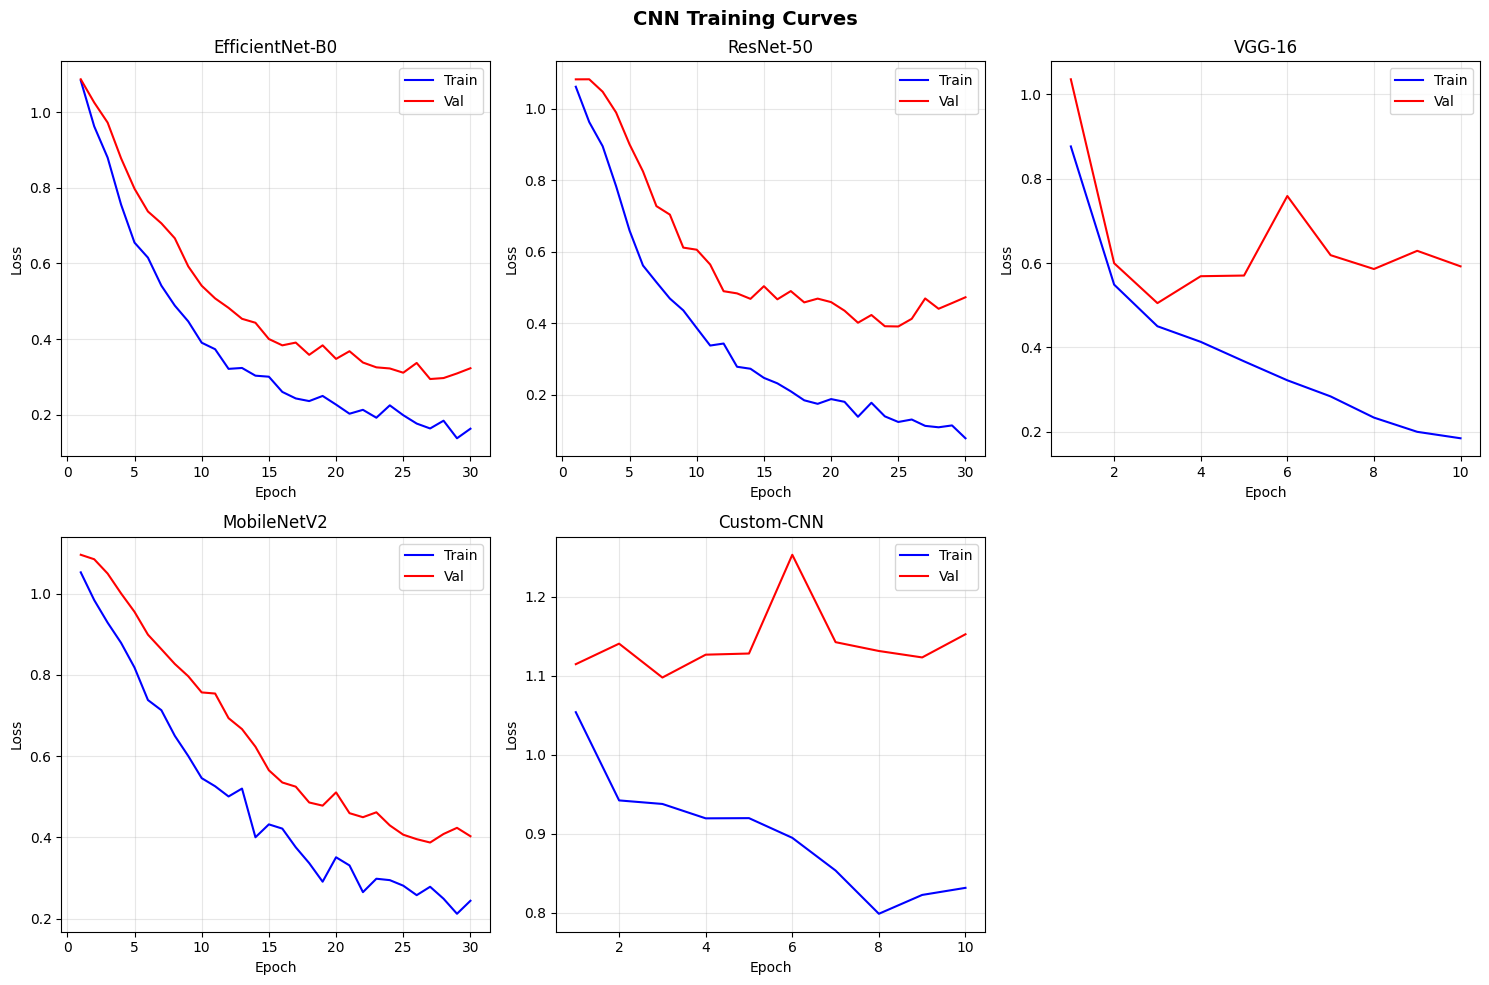

💾 Saved: cnn_training_curves.png


In [ ]:
# ============================================
# PLOT TRAINING CURVES
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('CNN Training Curves', fontsize=14, fontweight='bold')

for idx, (model_name, result) in enumerate(cnn_results.items()):
    ax = axes[idx // 3, idx % 3]
    history = result['history']
    epochs = range(1, len(history['train_loss']) + 1)

    ax.plot(epochs, history['train_loss'], 'b-', label='Train')
    ax.plot(epochs, history['val_loss'], 'r-', label='Val')
    ax.set_title(model_name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

if len(cnn_results) < 6:
    axes[-1, -1].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: cnn_training_curves.png")

---

## 8. 📊 CNN Test Set Evaluation

🐧 Now let's evaluate on the held-out test set!

In [ ]:
# ============================================
# EVALUATE ALL CNNs ON TEST SET
# ============================================

def evaluate_model(model, loader, criterion, device):
    model.eval()
    _, acc, preds, labels, probs = validate(model, loader, criterion, device)

    return {
        'accuracy': acc,
        'precision': precision_score(labels, preds, average='weighted'),
        'recall': recall_score(labels, preds, average='weighted'),
        'f1': f1_score(labels, preds, average='weighted'),
        'auc_roc': roc_auc_score(labels, probs, multi_class='ovr', average='weighted'),
        'predictions': preds,
        'true_labels': labels,
        'probabilities': probs
    }

cnn_test_results = {}
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

print("🧪 Evaluating CNNs on Test Set")
print("=" * 60)

for model_name, result in cnn_results.items():
    metrics = evaluate_model(result['model'], test_loader, criterion, DEVICE)
    cnn_test_results[model_name] = metrics
    print(f"{model_name}: Acc={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}")

🧪 Evaluating CNNs on Test Set
EfficientNet-B0: Acc=0.8291, F1=0.8342
ResNet-50: Acc=0.8462, F1=0.8486
VGG-16: Acc=0.7778, F1=0.7811
MobileNetV2: Acc=0.7778, F1=0.7789
Custom-CNN: Acc=0.2735, F1=0.1682


---

## 8b. 📊 🔄 CNN 2-CLASS TRAINING (Benign vs Malignant)

🐧 For fair comparison with Tabular models  
  
    
 ### 🐧💡 Why Train CNNs on 2 Classes?

The tabular models only classify **Benign vs Malignant** because radiomics requires lesion masks — Normal images have no lesions to analyze.

To make a fair apples-to-apples comparison, I am including training of CNNs on the same 2-class task.

| Comparison | Classes | Fair? |
|------------|---------|-------|
| Tabular vs CNN (3-class) | 2 vs 3 | ❌ No |
| Tabular vs CNN (2-class) | 2 vs 2 | ✅ Yes |

This tells us: **Is deep learning actually better, or was it just a harder task?**

In [ ]:
# ============================================
# FILTER DATA TO 2 CLASSES (Benign & Malignant only)
# ============================================

# Filter out Normal (class 0)
train_df_2c = train_df[train_df['class_encoded'] != 0].copy()
val_df_2c = val_df[val_df['class_encoded'] != 0].copy()
test_df_2c = test_df[test_df['class_encoded'] != 0].copy()

# Re-encode: Benign (1→0), Malignant (2→1)
train_df_2c['class_encoded'] = train_df_2c['class_encoded'] - 1
val_df_2c['class_encoded'] = val_df_2c['class_encoded'] - 1
test_df_2c['class_encoded'] = test_df_2c['class_encoded'] - 1

print("🐧 2-Class Data (Benign vs Malignant only)")
print(f"   Train: {len(train_df_2c)} (was {len(train_df)})")
print(f"   Val:   {len(val_df_2c)} (was {len(val_df)})")
print(f"   Test:  {len(test_df_2c)} (was {len(test_df)})")

🐧 2-Class Data (Benign vs Malignant only)
   Train: 453 (was 546)
   Val:   97 (was 117)
   Test:  97 (was 117)


In [ ]:
# ============================================
# 2-CLASS DATASETS & LOADERS
# ============================================

# Datasets
train_dataset_2c = BUSIDataset(train_df_2c, DATA_DIR, transform=train_transforms)
val_dataset_2c = BUSIDataset(val_df_2c, DATA_DIR, transform=eval_transforms)
test_dataset_2c = BUSIDataset(test_df_2c, DATA_DIR, transform=eval_transforms)

# Class weights for 2 classes (Benign, Malignant)
class_weights_2c = torch.FloatTensor([class_weights[1], class_weights[2]])

# Sample weights for 2-class training
sample_weights_2c = torch.FloatTensor([
    class_weights_2c[label].item() for label in train_df_2c['class_encoded']
])

train_sampler_2c = WeightedRandomSampler(
    weights=sample_weights_2c,
    num_samples=len(sample_weights_2c),
    replacement=True
)

# DataLoaders
train_loader_2c = DataLoader(
    train_dataset_2c, batch_size=BATCH_SIZE,
    sampler=train_sampler_2c, num_workers=2, pin_memory=True
)
val_loader_2c = DataLoader(
    val_dataset_2c, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader_2c = DataLoader(
    test_dataset_2c, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"✅ 2-Class DataLoaders ready!")
print(f"   Train batches: {len(train_loader_2c)}")

✅ 2-Class DataLoaders ready!
   Train batches: 15


In [ ]:
# ============================================
# TRAIN ALL CNN MODELS (2-CLASS)
# ============================================

NUM_CLASSES_2C = 2
cnn_results_2c = {}

print("🐧 Training CNNs on 2-Class Task (Benign vs Malignant)")
print("=" * 60)

for model_name, model_factory in CNN_MODELS.items():
    model = model_factory(NUM_CLASSES_2C)  # 2 classes now!

    result = train_cnn_model(
        model_name=f"{model_name} (2c)",
        model=model,
        train_loader=train_loader_2c,
        val_loader=val_loader_2c,
        num_epochs=NUM_EPOCHS,
        lr=LEARNING_RATE,
        class_weights=class_weights_2c,
        device=DEVICE,
        patience=PATIENCE,
        save_dir=MODELS_DIR
    )

    cnn_results_2c[model_name] = result
    torch.cuda.empty_cache()

print("\n🎉 All 2-class CNN models trained!")

🐧 Training CNNs on 2-Class Task (Benign vs Malignant)

🚀 Training EfficientNet-B0 (2c)
Epoch 01/30 | Train: 0.6929/0.5430 | Val: 0.6878/0.3505
Epoch 02/30 | Train: 0.6101/0.6887 | Val: 0.6355/0.4845
Epoch 03/30 | Train: 0.5650/0.6887 | Val: 0.6122/0.5876
Epoch 04/30 | Train: 0.5148/0.6865 | Val: 0.5616/0.7113
Epoch 05/30 | Train: 0.4686/0.7329 | Val: 0.5114/0.7732
Epoch 06/30 | Train: 0.4247/0.7903 | Val: 0.4684/0.7835
Epoch 07/30 | Train: 0.4027/0.7881 | Val: 0.4196/0.8144
Epoch 08/30 | Train: 0.3338/0.8411 | Val: 0.3814/0.8866
Epoch 09/30 | Train: 0.3237/0.8521 | Val: 0.3541/0.8866
Epoch 10/30 | Train: 0.2823/0.8720 | Val: 0.3453/0.8660
Epoch 11/30 | Train: 0.2767/0.8609 | Val: 0.3422/0.8557
Epoch 12/30 | Train: 0.2538/0.8764 | Val: 0.3128/0.8763
Epoch 13/30 | Train: 0.2246/0.8918 | Val: 0.3108/0.8866
Epoch 14/30 | Train: 0.2155/0.9007 | Val: 0.3058/0.8866
Epoch 15/30 | Train: 0.2154/0.9249 | Val: 0.3020/0.8660
Epoch 16/30 | Train: 0.1990/0.9139 | Val: 0.3106/0.8557
Epoch 17/30 | Tra

In [ ]:
# ============================================
# EVALUATE 2-CLASS CNNs ON TEST SET
# ============================================

cnn_2c_test_results = {}
criterion_2c = nn.CrossEntropyLoss(weight=class_weights_2c.to(DEVICE))

print("🧪 Evaluating 2-Class CNNs")
print("=" * 60)

for model_name, result in cnn_results_2c.items():
    model = result['model']
    _, acc, preds, labels, probs = validate(model, test_loader_2c, criterion_2c, DEVICE)

    # AUC for binary
    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except:
        auc = np.nan

    cnn_2c_test_results[model_name] = {
        'accuracy': acc,
        'precision': precision_score(labels, preds, average='weighted'),
        'recall': recall_score(labels, preds, average='weighted'),
        'f1': f1_score(labels, preds, average='weighted'),
        'auc_roc': auc,
        'predictions': preds,
        'true_labels': labels,
        'probabilities': probs,
        'training_time': result['training_time']
    }

    print(f"{model_name}: Acc={acc:.4f}, F1={cnn_2c_test_results[model_name]['f1']:.4f}, AUC={auc:.4f}")

🧪 Evaluating 2-Class CNNs
EfficientNet-B0: Acc=0.8763, F1=0.8773, AUC=0.9536
ResNet-50: Acc=0.8969, F1=0.8984, AUC=0.9594
VGG-16: Acc=0.8660, F1=0.8665, AUC=0.9487
MobileNetV2: Acc=0.8557, F1=0.8557, AUC=0.9487
Custom-CNN: Acc=0.7732, F1=0.7797, AUC=0.8573


---

## 9. 📈 Tabular Models (on Radiomics)

🐧 Now let's train our 5 tabular models on radiomics features!

💡 **Why radiomics?** These features are interpretable and clinically meaningful — radiologists use similar concepts. If tabular models perform well, we get both accuracy AND explainability!

In [ ]:
# ============================================
# PREPARE TABULAR DATA
# ============================================

metadata_cols = ['filename', 'class_name', 'class_encoded', 'split']
feature_cols = radiomics_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != 'class_encoded']  # Exclude target

X_train = radiomics_df[radiomics_df['split'] == 'train'][feature_cols].values
y_train = radiomics_df[radiomics_df['split'] == 'train']['class_encoded'].values
X_val = radiomics_df[radiomics_df['split'] == 'val'][feature_cols].values
y_val = radiomics_df[radiomics_df['split'] == 'val']['class_encoded'].values
X_test = radiomics_df[radiomics_df['split'] == 'test'][feature_cols].values
y_test = radiomics_df[radiomics_df['split'] == 'test']['class_encoded'].values

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"🐧 Tabular data ready!")
print(f"   Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

# quick check
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

print(f"Classes: {le.classes_}")
print(f"y_train unique: {np.unique(y_train)}")
print(f"y_test unique: {np.unique(y_test)}")
print("Tabular data only includes benign + malignant.")

🐧 Tabular data ready!
   Train: (452, 102), Val: (97, 102), Test: (96, 102)
Classes: [1 2]
y_train unique: [0 1]
y_test unique: [0 1]
Tabular data only includes benign + malignant.


🐧: Tabular models only classify Benign vs Malignant (2 classes) because radiomics requires lesion masks. CNNs classify all 3 classes since they work directly on image:

In [ ]:
# ============================================
# DEFINE TABULAR MODELS
# ============================================

# Convert PyTorch tensor weights to sklearn-friendly dict format
sklearn_weights = {i: class_weights[i].item() for i in range(len(class_weights))}

TABULAR_MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,  # More iterations to ensure convergence
        class_weight=sklearn_weights,
        random_state=SEED
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,  # 200 trees in the forest — more = stable but slower
        max_depth=15,  # Limit tree depth to prevent overfitting
        class_weight=sklearn_weights,
        random_state=SEED,
        n_jobs=-1  # Use all CPU cores for parallel training
    ),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,  # 200 boosting rounds
        max_depth=6,  # Shallower than RF — XGBoost trees are sequential, not independent
        learning_rate=0.1,  # How much each tree contributes — smaller = more conservative
        random_state=SEED,
        eval_metric='mlogloss'  # Multiclass log loss
        # Note: XGBoost handles class weights via sample_weight during fit()
    ),

    'SVM (RBF)': SVC(
        kernel='rbf',  # Radial basis function — good for non-linear boundaries
        class_weight=sklearn_weights,
        probability=True,  # Enable predict_proba() — needed for AUC-ROC
        random_state=SEED
    ),

    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),  # 3 hidden layers, shrinking
        max_iter=500,
        random_state=SEED,
        early_stopping=True  # Stop if validation score stops improving
    )
}

print(f"✅ Tabular models defined: {list(TABULAR_MODELS.keys())}")

✅ Tabular models defined: ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM (RBF)', 'MLP']


In [ ]:
# ============================================
# TRAIN ALL TABULAR MODELS
# ============================================

sample_weights_train = np.array([sklearn_weights[y] for y in y_train])
tabular_results = {}

print("🐧 Training Tabular Models")
print("=" * 60)

for model_name, model in TABULAR_MODELS.items():
    print(f"\n🔧 Training {model_name}...")
    start = time.time()

    if 'XGBoost' in model_name:
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train_scaled, y_train)

    train_time = time.time() - start
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)

    # Calculate AUC safely (fails if not all classes in test set)
    try:
        if y_proba.shape[1] == 2:
            # Binary classification — use probability of positive class
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            # Multiclass
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc = np.nan

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1': f1_score(y_test, y_pred, average='weighted'),
        'auc_roc': auc,
        'predictions': y_pred,
        'true_labels': y_test,
        'probabilities': y_proba,
        'training_time': train_time,
        'model': model
    }
    tabular_results[model_name] = metrics
    print(f"   ✅ {train_time:.2f}s | Acc: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")

print("\n🎉 All tabular models trained!")

🐧 Training Tabular Models

🔧 Training Logistic Regression...
   ✅ 0.01s | Acc: 0.9375, F1: 0.9354

🔧 Training Random Forest...
   ✅ 0.83s | Acc: 0.8333, F1: 0.8298

🔧 Training XGBoost...
   ✅ 0.64s | Acc: 0.9375, F1: 0.9354

🔧 Training SVM (RBF)...
   ✅ 0.05s | Acc: 0.8229, F1: 0.7980

🔧 Training MLP...
   ✅ 0.34s | Acc: 0.8854, F1: 0.8823

🎉 All tabular models trained!


---

## 10. 🏆 Grand Comparison!

🐧 The moment of truth — who wins the AMEEMAW Model Championship? 🎖️

In [ ]:
# ============================================
# FULL COMPARISON: All 15 Models!
# Tabular (2-class) vs CNN (2-class) vs CNN (3-class)
# ============================================

comparison_data = []

# CNN 3-class results
for name, metrics in cnn_test_results.items():
    comparison_data.append({
        'Model': name, 'Type': 'CNN (3-class)',
        'Accuracy': metrics['accuracy'], 'Precision': metrics['precision'],
        'Recall': metrics['recall'], 'F1 Score': metrics['f1'],
        'AUC-ROC': metrics['auc_roc'], 'Time (s)': cnn_results[name]['training_time']
    })

# CNN 2-class results
for name, metrics in cnn_2c_test_results.items():
    comparison_data.append({
        'Model': name, 'Type': 'CNN (2-class)',
        'Accuracy': metrics['accuracy'], 'Precision': metrics['precision'],
        'Recall': metrics['recall'], 'F1 Score': metrics['f1'],
        'AUC-ROC': metrics['auc_roc'], 'Time (s)': metrics['training_time']
    })

# Tabular 2-class results
for name, metrics in tabular_results.items():
    comparison_data.append({
        'Model': name, 'Type': 'Tabular (2-class)',
        'Accuracy': metrics['accuracy'], 'Precision': metrics['precision'],
        'Recall': metrics['recall'], 'F1 Score': metrics['f1'],
        'AUC-ROC': metrics['auc_roc'], 'Time (s)': metrics['training_time']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)
comparison_df.insert(0, 'Rank', range(1, len(comparison_df) + 1))

print("🏆 FULL MODEL COMPARISON (15 Models!)")
print("=" * 100)
print(comparison_df.to_string(index=False))

🏆 FULL MODEL COMPARISON (15 Models!)
 Rank               Model              Type  Accuracy  Precision   Recall  F1 Score  AUC-ROC   Time (s)
    1 Logistic Regression Tabular (2-class)  0.937500   0.942708 0.937500  0.935386 0.952020   0.014570
    2             XGBoost Tabular (2-class)  0.937500   0.942708 0.937500  0.935386 0.983838   0.644540
    3           ResNet-50     CNN (2-class)  0.896907   0.903159 0.896907  0.898420 0.959433 255.175069
    4                 MLP Tabular (2-class)  0.885417   0.885035 0.885417  0.882299 0.896970   0.335531
    5     EfficientNet-B0     CNN (2-class)  0.876289   0.879051 0.876289  0.877270 0.953568 220.732109
    6              VGG-16     CNN (2-class)  0.865979   0.867283 0.865979  0.866532 0.948680 225.319671
    7         MobileNetV2     CNN (2-class)  0.855670   0.855670 0.855670  0.855670 0.948680 212.577251
    8           ResNet-50     CNN (3-class)  0.846154   0.861099 0.846154  0.848578 0.953090 303.851038
    9     EfficientNet-B0  

### 🐧💡 What the Results Tell Us

**The Fair Comparison (2-class vs 2-class):**

| Model Type | Best F1 | Avg F1 |
|------------|---------|--------|
| Tabular (2-class) | 93.5% (Logistic Regression) | 87.6% |
| CNN (2-class) | 89.8% (ResNet-50) | 85.5% |
| CNN (3-class) | 84.9% (ResNet-50) | 68.2% |

**Key Findings:**

1. **Task difficulty matters!** Same model (ResNet-50) drops from 89.8% → 84.9% when adding the Normal class. The 3-class task is genuinely harder.

2. **CNNs are competitive when compared fairly.** Looking at best models: CNN 2-class (89.8%) vs Tabular (93.5%) — only ~4% difference! Deep learning isn't losing badly, it was just solving a harder problem.

3. **Tabular wins overall** — Logistic Regression (93.5%) beats all CNNs. For small datasets (~780 images), handcrafted radiomics features remain powerful.

4. **Transfer learning is essential.** Custom-CNN (no pretraining) fails badly: 78% on 2-class, 27% on 3-class. This drags down CNN averages but teaches an important lesson — ImageNet pretraining is crucial for small medical datasets!

5. **ResNet-50 is the CNN champion** — Outperforms EfficientNet-B0 on both 2-class (89.8% vs 87.7%) and 3-class (84.9% vs 83.4%) tasks.

**For AMEEMAW Deployment:**   
I'm using **ResNet-50 (3-class)** because real users may upload images without lesions — I need to identify Normal cases too. The slight accuracy trade-off is worth the broader coverage.

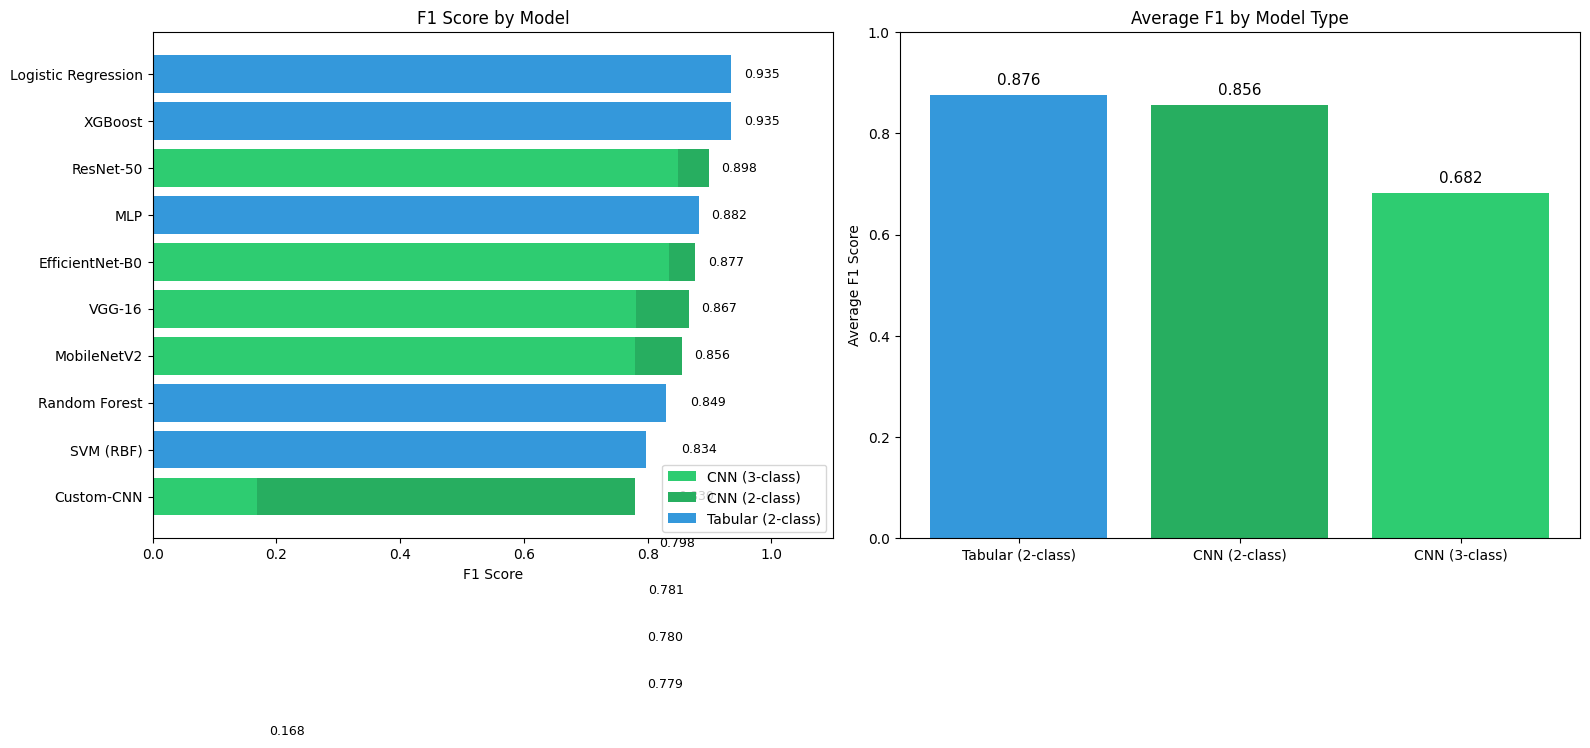

💾 Saved: model_comparison.png


In [ ]:
# ============================================
# VISUALIZE COMPARISON
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Color by type
color_map = {
    'CNN (3-class)': '#2ecc71',    # Green
    'CNN (2-class)': '#27ae60',    # Dark green
    'Tabular (2-class)': '#3498db' # Blue
}
colors = [color_map[t] for t in comparison_df['Type']]

# --- Plot 1: Horizontal bar chart (F1 Score) ---
axes[0].barh(comparison_df['Model'], comparison_df['F1 Score'], color=colors)
axes[0].set_xlabel('F1 Score')
axes[0].set_title('F1 Score by Model')
axes[0].set_xlim([0, 1.1])  # Extra space for labels
axes[0].invert_yaxis()  # Best at top

# Add value labels
for i, v in enumerate(comparison_df['F1 Score']):
    axes[0].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='CNN (3-class)'),
    Patch(facecolor='#27ae60', label='CNN (2-class)'),
    Patch(facecolor='#3498db', label='Tabular (2-class)')
]
axes[0].legend(handles=legend_elements, loc='lower right')

# --- Plot 2: Grouped by Type (average F1) ---
type_avg = comparison_df.groupby('Type')['F1 Score'].mean().sort_values(ascending=False)
bars = axes[1].bar(type_avg.index, type_avg.values, color=[color_map[t] for t in type_avg.index])
axes[1].set_ylabel('Average F1 Score')
axes[1].set_title('Average F1 by Model Type')
axes[1].set_ylim([0, 1])

# Add value labels
for bar, val in zip(bars, type_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: model_comparison.png")

In [ ]:
# ============================================
# KEY INSIGHTS
# ============================================

best_overall = comparison_df.iloc[0]

# Filter by type (updated names)
best_cnn_3c = comparison_df[comparison_df['Type'] == 'CNN (3-class)'].iloc[0]
best_cnn_2c = comparison_df[comparison_df['Type'] == 'CNN (2-class)'].iloc[0]
best_tabular = comparison_df[comparison_df['Type'] == 'Tabular (2-class)'].iloc[0]

# Averages
cnn_3c_avg = comparison_df[comparison_df['Type'] == 'CNN (3-class)']['F1 Score'].mean()
cnn_2c_avg = comparison_df[comparison_df['Type'] == 'CNN (2-class)']['F1 Score'].mean()
tabular_avg = comparison_df[comparison_df['Type'] == 'Tabular (2-class)']['F1 Score'].mean()

print("🐧💡 KEY INSIGHTS")
print("=" * 60)
print(f"\n🥇 BEST OVERALL: {best_overall['Model']} ({best_overall['Type']}) — F1: {best_overall['F1 Score']:.4f}")
print(f"\n🖼️ Best CNN (3-class): {best_cnn_3c['Model']} — F1: {best_cnn_3c['F1 Score']:.4f}")
print(f"🖼️ Best CNN (2-class): {best_cnn_2c['Model']} — F1: {best_cnn_2c['F1 Score']:.4f}")
print(f"📊 Best Tabular:       {best_tabular['Model']} — F1: {best_tabular['F1 Score']:.4f}")

print(f"\n📈 AVERAGE F1 BY TYPE:")
print(f"   CNN (3-class): {cnn_3c_avg:.4f}")
print(f"   CNN (2-class): {cnn_2c_avg:.4f}")
print(f"   Tabular:       {tabular_avg:.4f}")

print("\n💡 FAIR COMPARISON (2-class vs 2-class):")
if cnn_2c_avg > tabular_avg:
    print(f"   CNNs beat Tabular by {cnn_2c_avg - tabular_avg:.4f} — deep learning wins!")
elif tabular_avg > cnn_2c_avg:
    print(f"   Tabular beats CNNs by {tabular_avg - cnn_2c_avg:.4f} — radiomics are powerful!")
else:
    print("   They're tied! Both approaches are valid.")

🐧💡 KEY INSIGHTS

🥇 BEST OVERALL: Logistic Regression (Tabular (2-class)) — F1: 0.9354

🖼️ Best CNN (3-class): ResNet-50 — F1: 0.8486
🖼️ Best CNN (2-class): ResNet-50 — F1: 0.8984
📊 Best Tabular:       Logistic Regression — F1: 0.9354

📈 AVERAGE F1 BY TYPE:
   CNN (3-class): 0.6822
   CNN (2-class): 0.8555
   Tabular:       0.8762

💡 FAIR COMPARISON (2-class vs 2-class):
   Tabular beats CNNs by 0.0207 — radiomics are powerful!


---

## 11. 🔍 Confusion Matrices

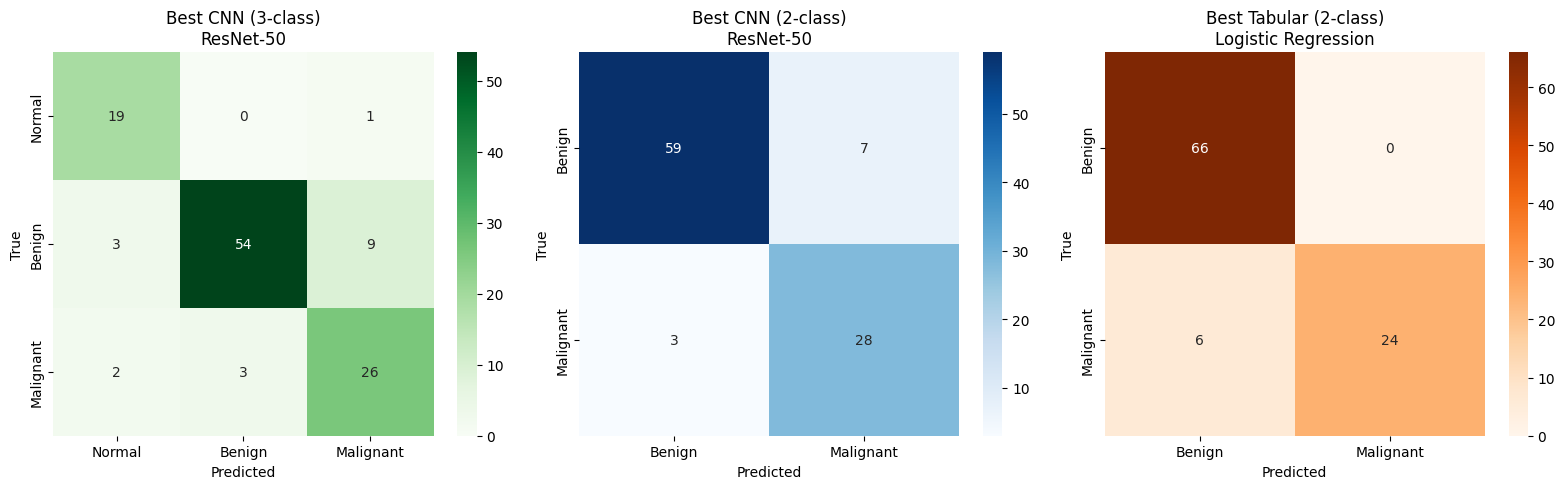

💾 Saved: confusion_matrices_best.png


In [ ]:
# ============================================
# CONFUSION MATRICES (Best of Each Type)
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Best CNN (3-class) ---
cm_cnn3 = confusion_matrix(
    cnn_test_results[best_cnn_3c['Model']]['true_labels'],
    cnn_test_results[best_cnn_3c['Model']]['predictions']
)
sns.heatmap(cm_cnn3, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Benign', 'Malignant'],
            yticklabels=['Normal', 'Benign', 'Malignant'], ax=axes[0])
axes[0].set_title(f"Best CNN (3-class)\n{best_cnn_3c['Model']}")
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# --- Best CNN (2-class) ---
cm_cnn2 = confusion_matrix(
    cnn_2c_test_results[best_cnn_2c['Model']]['true_labels'],
    cnn_2c_test_results[best_cnn_2c['Model']]['predictions']
)
sns.heatmap(cm_cnn2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=axes[1])
axes[1].set_title(f"Best CNN (2-class)\n{best_cnn_2c['Model']}")
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

# --- Best Tabular (2-class) ---
cm_tab = confusion_matrix(
    tabular_results[best_tabular['Model']]['true_labels'],
    tabular_results[best_tabular['Model']]['predictions']
)
sns.heatmap(cm_tab, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=axes[2])
axes[2].set_title(f"Best Tabular (2-class)\n{best_tabular['Model']}")
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices_best.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: confusion_matrices_best.png")

### 🐧💡 Understanding Confusion Matrices in Healthcare

Not all mistakes are equal!

| Mistake | Meaning | Severity |
|---------|---------|----------|
| Malignant → Benign/Normal | **False Negative** (missed cancer) | ⚠️ CRITICAL |
| Benign/Normal → Malignant | **False Positive** (unnecessary worry) | Moderate |

💡 **For medical AI, we prioritize RECALL for malignant** — missing cancer is far worse than a false alarm!

In [ ]:
# ============================================
# MALIGNANT RECALL CHECK
# ============================================

# --- Best Overall Model ---
print(f"\n📋 Classification Report: {best_overall['Model']} ({best_overall['Type']})")
print("=" * 60)

if best_overall['Type'] == 'CNN (3-class)':
    y_true = cnn_test_results[best_overall['Model']]['true_labels']
    y_pred = cnn_test_results[best_overall['Model']]['predictions']
    class_names = ['Normal', 'Benign', 'Malignant']
    malignant_label = 2
elif best_overall['Type'] == 'CNN (2-class)':
    y_true = cnn_2c_test_results[best_overall['Model']]['true_labels']
    y_pred = cnn_2c_test_results[best_overall['Model']]['predictions']
    class_names = ['Benign', 'Malignant']
    malignant_label = 1
else:  # Tabular (2-class)
    y_true = tabular_results[best_overall['Model']]['true_labels']
    y_pred = tabular_results[best_overall['Model']]['predictions']
    class_names = ['Benign', 'Malignant']
    malignant_label = 1

print(classification_report(y_true, y_pred, target_names=class_names))

mal_recall = recall_score(y_true, y_pred, labels=[malignant_label], average=None)[0]
print(f"\n⚠️ MALIGNANT RECALL: {mal_recall:.4f}")
if mal_recall >= 0.9:
    print("   ✅ Excellent! Catching most malignant cases.")
elif mal_recall >= 0.8:
    print("   ⚡ Good, but room for improvement.")
else:
    print("   ⚠️ Need to improve! Missing too many malignant cases.")

# --- Deployment Model (CNN 3-class) ---
print(f"\n\n📋 Classification Report: {best_cnn_3c['Model']} — DEPLOYMENT MODEL")
print("=" * 60)

y_true_deploy = cnn_test_results[best_cnn_3c['Model']]['true_labels']
y_pred_deploy = cnn_test_results[best_cnn_3c['Model']]['predictions']

print(classification_report(y_true_deploy, y_pred_deploy, target_names=['Normal', 'Benign', 'Malignant']))

mal_recall_deploy = recall_score(y_true_deploy, y_pred_deploy, labels=[2], average=None)[0]
print(f"\n⚠️ MALIGNANT RECALL (Deployment): {mal_recall_deploy:.4f}")
if mal_recall_deploy >= 0.9:
    print("   ✅ Excellent! Catching most malignant cases.")
elif mal_recall_deploy >= 0.8:
    print("   ⚡ Good, but room for improvement.")
else:
    print("   ⚠️ Need to improve! Missing too many malignant cases.")

print("\n💡 This is the model I'll deploy in AMEEMAW — it handles all 3 classes!")


📋 Classification Report: Logistic Regression (Tabular (2-class))
              precision    recall  f1-score   support

      Benign       0.92      1.00      0.96        66
   Malignant       1.00      0.80      0.89        30

    accuracy                           0.94        96
   macro avg       0.96      0.90      0.92        96
weighted avg       0.94      0.94      0.94        96


⚠️ MALIGNANT RECALL: 0.8000
   ⚡ Good, but room for improvement.


📋 Classification Report: ResNet-50 — DEPLOYMENT MODEL
              precision    recall  f1-score   support

      Normal       0.79      0.95      0.86        20
      Benign       0.95      0.82      0.88        66
   Malignant       0.72      0.84      0.78        31

    accuracy                           0.85       117
   macro avg       0.82      0.87      0.84       117
weighted avg       0.86      0.85      0.85       117


⚠️ MALIGNANT RECALL (Deployment): 0.8387
   ⚡ Good, but room for improvement.

💡 This is the model I'll

---

## 12. 💾 Save Everything!

In [ ]:
# ============================================
# SAVE ALL RESULTS
# ============================================

# Comparison table
comparison_df.to_csv(PROCESSED_DIR / 'model_comparison.csv', index=False)
print("💾 Saved: model_comparison.csv")

# Best model info (updated for 3 types)
best_info = {
    'best_overall': best_overall['Model'],
    'best_overall_type': best_overall['Type'],
    'best_overall_f1': float(best_overall['F1 Score']),
    'best_cnn_3class': best_cnn_3c['Model'],
    'best_cnn_3class_f1': float(best_cnn_3c['F1 Score']),
    'best_cnn_2class': best_cnn_2c['Model'],
    'best_cnn_2class_f1': float(best_cnn_2c['F1 Score']),
    'best_tabular': best_tabular['Model'],
    'best_tabular_f1': float(best_tabular['F1 Score']),
    'timestamp': datetime.now().isoformat()
}
with open(MODELS_DIR / 'best_model_info.json', 'w') as f:
    json.dump(best_info, f, indent=2)
print("💾 Saved: best_model_info.json")

# Tabular models
for name, metrics in tabular_results.items():
    fname = name.lower().replace(' ', '_').replace('(', '').replace(')', '') + '.pkl'
    with open(MODELS_DIR / fname, 'wb') as f:
        pickle.dump(metrics['model'], f)
    print(f"💾 Saved: {fname}")

print("\n✅ All results saved!")

💾 Saved: model_comparison.csv
💾 Saved: best_model_info.json
💾 Saved: logistic_regression.pkl
💾 Saved: random_forest.pkl
💾 Saved: xgboost.pkl
💾 Saved: svm_rbf.pkl
💾 Saved: mlp.pkl

✅ All results saved!


---

## 13. 📝 Summary

🐧 Here's what's accomplished:

## 🐧 MODEL TRAINING COMPLETE!

---

### 📊 What I Trained
- **5 CNN Models** (3-class): EfficientNet-B0, ResNet-50, VGG-16, MobileNetV2, Custom-CNN
- **5 CNN Models** (2-class): Same architectures, for fair comparison
- **5 Tabular Models** (2-class): Logistic Regression, Random Forest, XGBoost, SVM, MLP
- **Total: 15 model variants compared!**

---

### 💾 Files Generated
| Location | Files |
|----------|-------|
| `models/` | `*.pth` (CNN weights), `*.pkl` (Tabular models), `best_model_info.json` |
| `data/processed/` | `model_comparison.csv` |
| `reports/figures/` | `cnn_training_curves.png`, `model_comparison.png`, `confusion_matrices_best.png` |

---

### 🏆 Final Decision: Why CNN (3-class) for Deployment?

**Logistic Regression (93.5% F1) beat all CNNs. Why not use that?**

Here's why I'm choosing **ResNet-50 (3-class)** for AMEEMAW:

| Factor | Tabular (2-class) | CNN (3-class) |
|--------|-------------------|---------------|
| **Accuracy** | ✅ Higher (93.5% F1) | ⚡ Good (84.9% F1) |
| **Handles Normal cases** | ❌ No — needs lesion mask | ✅ Yes — works on any image |
| **User experience** | ❌ "Upload failed" for healthy images | ✅ "Your scan appears Normal" |
| **Real-world usability** | ❌ Limited | ✅ Full coverage |

**The problem with Tabular:**
- Radiomics requires a **lesion mask** to extract features
- Normal images have **no lesions** → no mask → **can't classify**
- In the real world, I don't know if an image has a lesion until I classify it!

**The CNN advantage:**
- Works directly on **raw pixels** — no preprocessing needed
- Can say "Normal" when there's no lesion
- Users upload any ultrasound → get an answer

**Why ResNet-50 over other CNNs?**
- 🏆 Best CNN performance on both 2-class (89.8% F1) and 3-class (84.9% F1)
- Battle-tested architecture — widely used in medical imaging research
- Good balance of accuracy and model size

**Think of it this way:** 🐧
> A model that's 93% accurate but only works 70% of the time is worse than a model that's 85% accurate but works 100% of the time!

**Bottom line:** I'm trading ~9% accuracy for **complete coverage**. That's the right trade-off for a real-world medical education tool.

---

### 💡 Key Takeaways
1. **Task difficulty matters** — 3-class is harder than 2-class (ResNet-50 drops 89.8% → 84.9%)
2. **Transfer learning is essential** — Custom-CNN without pretraining fails badly (27% vs 85%)
3. **Radiomics are powerful but limited** — High accuracy, but can't handle Normal cases
4. **Best metric ≠ Best deployment choice** — Real-world constraints matter!
5. **Always prioritize malignant recall** — Missing cancer is worse than false alarms

---

### 🔮 Next Steps
- **Notebook 04:** Explainability (Grad-CAM + SHAP)
- **Notebook 05:** Bias Audit
- **Notebook 06:** GenAI Integration (Nana!)

---

### 🐧 Continue to Explainability ipynb!

We'll make the models **explainable** with Grad-CAM and SHAP — because in healthcare, "why" matters just as much as "what". 💡

---
#### End of Notebook
---